# Stage 7 Enrichment Results Inspection

This notebook summarizes ORA and BES outputs generated by `scripts/04_run_enrichment.py`.

It reads artifacts under:
- `results/enrichment/<method>/summary.parquet`
- `results/enrichment/<method>/<library>/terms.parquet`
- `results/enrichment/<method>/<library>/bes_components.json`
- `results/enrichment/_null_cache/<library>/size_<N>_seed_<seed>.npz`

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "results").exists() and (cwd / "scripts").exists():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "results").exists() and (cwd.parent / "scripts").exists():
        return cwd.parent
    raise FileNotFoundError(
        "Could not resolve repository root from current working directory. "
        "Open the notebook in the project workspace root or notebooks folder."
    )


REPO_ROOT = resolve_repo_root()
ENRICHMENT_DIR = REPO_ROOT / "results" / "enrichment"
NULL_CACHE_DIR = ENRICHMENT_DIR / "_null_cache"

print(f"Repo root: {REPO_ROOT}")
print(f"Enrichment dir: {ENRICHMENT_DIR}")

Repo root: C:\Programmering\exjobb\MSc26_Proteomics
Enrichment dir: C:\Programmering\exjobb\MSc26_Proteomics\results\enrichment


## Load Method Summaries And Metadata

In [2]:
def load_enrichment_summaries(base_dir: Path) -> tuple[pd.DataFrame, dict[str, dict]]:
    if not base_dir.exists():
        raise FileNotFoundError(f"Enrichment directory not found: {base_dir}")

    summary_frames: list[pd.DataFrame] = []
    meta_by_method: dict[str, dict] = {}

    for method_dir in sorted(base_dir.iterdir()):
        if not method_dir.is_dir() or method_dir.name == "_null_cache":
            continue

        summary_path = method_dir / "summary.parquet"
        meta_path = method_dir / "meta.json"
        if not summary_path.exists():
            continue

        method = method_dir.name
        df = pd.read_parquet(summary_path).copy()
        df["method"] = method
        summary_frames.append(df)

        if meta_path.exists():
            meta_by_method[method] = json.loads(meta_path.read_text(encoding="utf-8"))

    if not summary_frames:
        raise FileNotFoundError(f"No summary.parquet files found under {base_dir}")

    summaries = pd.concat(summary_frames, ignore_index=True)
    return summaries, meta_by_method


summaries, meta_by_method = load_enrichment_summaries(ENRICHMENT_DIR)
required_cols = {"method", "library", "gene_list_size", "bes_raw", "bes_z", "bes_p_emp", "n_significant_terms"}
missing = required_cols.difference(summaries.columns)
if missing:
    raise ValueError(f"Missing expected summary columns: {sorted(missing)}")

print(f"Methods loaded: {sorted(summaries['method'].unique().tolist())}")
print(f"Libraries loaded: {sorted(summaries['library'].unique().tolist())}")
print(f"Rows: {len(summaries):,}")

display(summaries.sort_values(["library", "method"]).reset_index(drop=True))

Methods loaded: ['random', 'ttest']
Libraries loaded: ['GO_Biological_Process_2023', 'KEGG_2021_Human', 'Reactome_2022']
Rows: 6


,library,gene_list_size,bes_raw,bes_z,bes_p_emp,n_significant_terms,method
0,GO_Biological_Process_2023,20,0.0,-0.242536,1.0,0,random
1,GO_Biological_Process_2023,20,0.0,-0.242536,1.0,0,ttest
2,KEGG_2021_Human,20,0.0,NaN,1.0,0,random
3,KEGG_2021_Human,20,0.0,NaN,1.0,0,ttest
4,Reactome_2022,20,0.0,NaN,1.0,0,random
5,Reactome_2022,20,0.0,NaN,1.0,0,ttest


In [3]:
method_coverage = (
    summaries.groupby("method", as_index=False)
    .agg(
        n_libraries=("library", "nunique"),
        gene_list_size=("gene_list_size", "first"),
        total_significant_terms=("n_significant_terms", "sum"),
        max_bes_raw=("bes_raw", "max"),
        max_bes_z=("bes_z", "max"),
        min_p_emp=("bes_p_emp", "min"),
    )
)

display(method_coverage.sort_values("method").reset_index(drop=True))

if meta_by_method:
    print("Meta overview")
    meta_rows = []
    for method, meta in sorted(meta_by_method.items()):
        meta_rows.append(
            {
                "method": method,
                "seed": meta.get("seed"),
                "b_perm": meta.get("b_perm"),
                "skip_null": meta.get("skip_null"),
                "background_size": meta.get("background_size"),
                "gene_list_size": meta.get("gene_list_size"),
            }
        )
    display(pd.DataFrame(meta_rows))

,method,n_libraries,gene_list_size,total_significant_terms,max_bes_raw,max_bes_z,min_p_emp
0,random,3,20,0,0.0,-0.242536,1.0
1,ttest,3,20,0,0.0,-0.242536,1.0


Meta overview


,method,seed,b_perm,skip_null,background_size,gene_list_size
0,random,42,1000,False,9511,20
1,ttest,42,1000,False,9511,20


## BES Comparison Plots

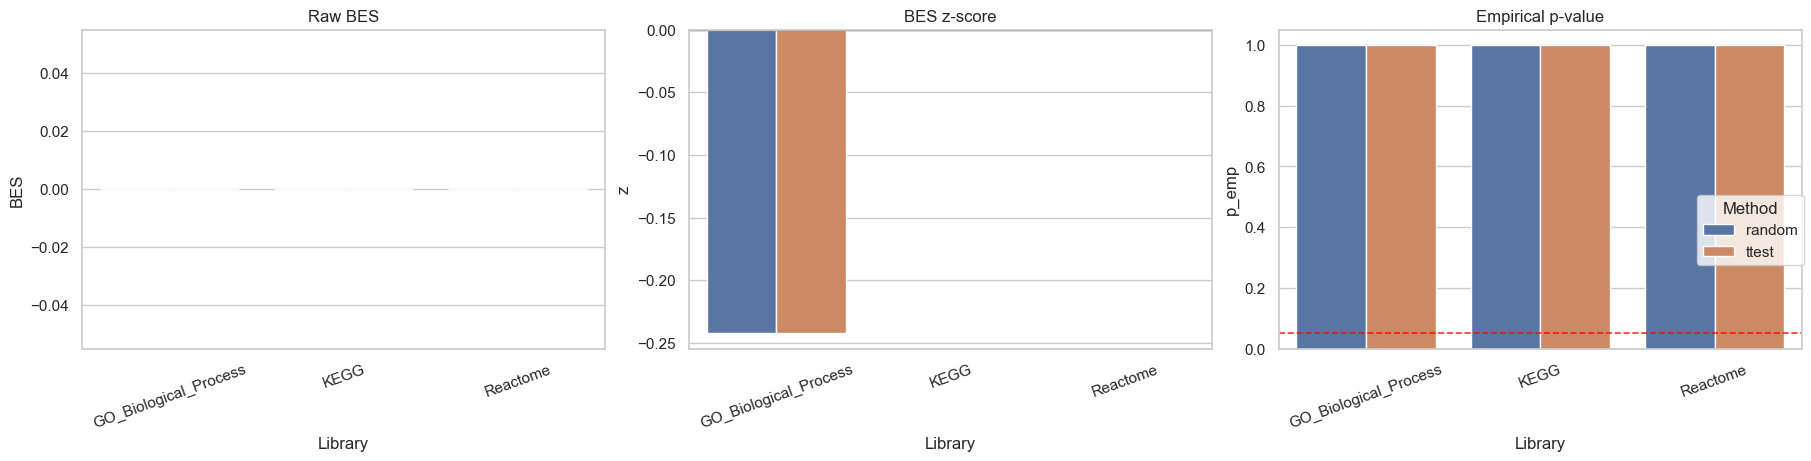

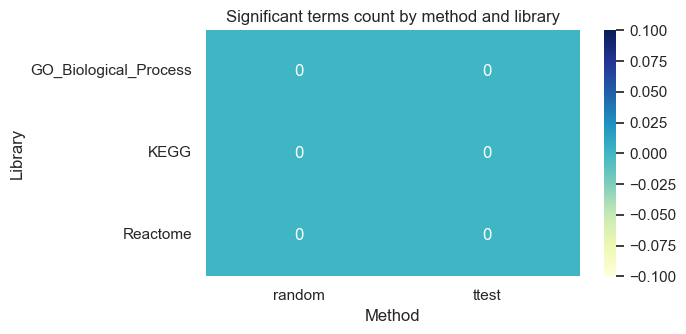

In [4]:
plot_df = summaries.copy()
plot_df["library_short"] = (
    plot_df["library"]
    .str.replace("_2023", "", regex=False)
    .str.replace("_2022", "", regex=False)
    .str.replace("_2021_Human", "", regex=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

sns.barplot(data=plot_df, x="library_short", y="bes_raw", hue="method", ax=axes[0])
axes[0].set_title("Raw BES")
axes[0].set_xlabel("Library")
axes[0].set_ylabel("BES")

sns.barplot(data=plot_df, x="library_short", y="bes_z", hue="method", ax=axes[1])
axes[1].set_title("BES z-score")
axes[1].set_xlabel("Library")
axes[1].set_ylabel("z")
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.6)

sns.barplot(data=plot_df, x="library_short", y="bes_p_emp", hue="method", ax=axes[2])
axes[2].set_title("Empirical p-value")
axes[2].set_xlabel("Library")
axes[2].set_ylabel("p_emp")
axes[2].axhline(0.05, color="red", linestyle="--", linewidth=1.2, alpha=0.8)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

handles, labels = axes[2].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(handles, labels, title="Method", loc="center right")

plt.show()

pivot_sig = (
    plot_df.pivot(index="library_short", columns="method", values="n_significant_terms")
    .sort_index()
)

plt.figure(figsize=(7, 3.5))
sns.heatmap(pivot_sig, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Significant terms count by method and library")
plt.xlabel("Method")
plt.ylabel("Library")
plt.tight_layout()
plt.show()

## Inspect Term Tables

Use the controls in the next cell to inspect the top-ranked terms (smallest q-values) for any method and library.

In [5]:
available_methods = sorted(summaries["method"].unique().tolist())
available_libraries = sorted(summaries["library"].unique().tolist())

SELECT_METHOD = available_methods[0]
SELECT_LIBRARY = available_libraries[0]
TOP_N_TERMS = 20

terms_path = ENRICHMENT_DIR / SELECT_METHOD / SELECT_LIBRARY / "terms.parquet"
if not terms_path.exists():
    raise FileNotFoundError(f"Terms file not found: {terms_path}")

terms_df = pd.read_parquet(terms_path).copy()
terms_df = terms_df.sort_values(["q_value", "p_value", "term"], kind="mergesort")

print(f"Method: {SELECT_METHOD}")
print(f"Library: {SELECT_LIBRARY}")
print(f"Rows in term table: {len(terms_df):,}")

cols = [c for c in ["term", "q_value", "p_value", "overlap_size", "term_size", "genes"] if c in terms_df.columns]
display(terms_df.loc[:, cols].head(TOP_N_TERMS))

Method: random
Library: GO_Biological_Process_2023
Rows in term table: 250


,term,q_value,p_value,overlap_size,term_size,genes
0,Spindle Assembly (GO:0051225),0.096345,0.002536,2,2,NEK6;RCC1
1,Microtubule Cytoskeleton Organization Involved...,0.096345,0.002971,2,2,NEK6;RCC1
2,Sensory Organ Morphogenesis (GO:0090596),0.096345,0.004201,1,1,COL5A2
3,Mitotic Spindle Organization (GO:0007052),0.096345,0.005836,2,2,NEK6;RCC1
4,Embryonic Hindlimb Morphogenesis (GO:0035116),0.096345,0.006296,1,1,WNT7A
5,Hindlimb Morphogenesis (GO:0035137),0.096345,0.006296,1,1,WNT7A
6,Multi-Pass Transmembrane Protein Insertion Int...,0.096345,0.006296,1,1,NOMO2
7,Neuroepithelial Cell Differentiation (GO:0060563),0.096345,0.006296,1,1,FGF8
8,Axon Development (GO:0061564),0.096345,0.007137,2,2,WNT7A;NREP
9,Regulation Of Cell Cycle Process (GO:0010564),0.096345,0.008072,2,2,RCC1;FSD1


In [6]:
components_path = ENRICHMENT_DIR / SELECT_METHOD / SELECT_LIBRARY / "bes_components.json"
if not components_path.exists():
    raise FileNotFoundError(f"BES components file not found: {components_path}")

components_payload = json.loads(components_path.read_text(encoding="utf-8"))
core_fields = {
    "method": components_payload.get("method"),
    "library": components_payload.get("library"),
    "gene_list_size": components_payload.get("gene_list_size"),
    "background_size": components_payload.get("background_size"),
    "bes_raw": components_payload.get("bes_raw"),
    "bes_z": components_payload.get("bes_z"),
    "bes_p_emp": components_payload.get("bes_p_emp"),
    "null_effective": components_payload.get("null_effective"),
}

print("BES components summary")
display(pd.DataFrame([core_fields]))

term_contrib = components_payload.get("bes_components", {}).get("per_term_contributions", [])
if term_contrib:
    contrib_df = pd.DataFrame(term_contrib).sort_values("contribution", ascending=False)
    display(contrib_df.head(20))
else:
    print("No per-term contributions available (no significant terms under current q-threshold).")

BES components summary


,method,library,gene_list_size,background_size,bes_raw,bes_z,bes_p_emp,null_effective
0,random,GO_Biological_Process_2023,20,9511,0.0,-0.242536,1.0,18


No per-term contributions available (no significant terms under current q-threshold).


In [7]:
cache_rows = []
if NULL_CACHE_DIR.exists():
    for library_dir in sorted(NULL_CACHE_DIR.iterdir()):
        if not library_dir.is_dir():
            continue
        for npz_path in sorted(library_dir.glob("size_*_seed_*.npz")):
            data = np.load(npz_path)
            null_vals = data["null_values"]
            valid = null_vals[np.isfinite(null_vals)]
            cache_rows.append(
                {
                    "library": library_dir.name,
                    "cache_file": npz_path.name,
                    "n_total": int(len(null_vals)),
                    "n_valid": int(len(valid)),
                    "mean": float(valid.mean()) if len(valid) else np.nan,
                    "std": float(valid.std(ddof=0)) if len(valid) else np.nan,
                    "min": float(valid.min()) if len(valid) else np.nan,
                    "max": float(valid.max()) if len(valid) else np.nan,
                }
            )

cache_df = pd.DataFrame(cache_rows)
if cache_df.empty:
    print("No null-cache files found.")
else:
    display(cache_df.sort_values(["library", "cache_file"]).reset_index(drop=True))

,library,cache_file,n_total,n_valid,mean,std,min,max
0,GO_Biological_Process_2023,size_20_seed_42.npz,20,18,0.011265,0.046447,0.0,0.202770
1,GO_Biological_Process_2023,size_20_seed_43.npz,5,5,0.033817,0.067635,0.0,0.169087
2,KEGG_2021_Human,size_20_seed_42.npz,20,19,0.000000,0.000000,0.0,0.000000
3,KEGG_2021_Human,size_20_seed_43.npz,5,5,0.000000,0.000000,0.0,0.000000
4,Reactome_2022,size_20_seed_42.npz,20,19,0.000000,0.000000,0.0,0.000000
5,Reactome_2022,size_20_seed_43.npz,5,5,0.021255,0.042509,0.0,0.106273


## Gene-list provenance (full-data selection)

Each method's gene list now derives from `results/selection/<method>/full_data_ranking.parquet` via `scripts/04_run_enrichment.py`. The cell below surfaces the `gene_list.json` written alongside each enrichment run so we can see whether the list came from the `significant` mask or fell back to the top-`STABILITY_MIN_SIZE` ranking.

In [ ]:
gene_list_rows = []
for method_dir in sorted(ENRICHMENT_DIR.iterdir()):
    if not method_dir.is_dir() or method_dir.name == "_null_cache":
        continue
    gene_list_path = method_dir / "gene_list.json"
    if not gene_list_path.exists():
        continue
    payload = json.loads(gene_list_path.read_text(encoding="utf-8"))
    gene_list_rows.append(
        {
            "method": payload.get("method", method_dir.name),
            "source": payload.get("source"),
            "min_size": payload.get("min_size"),
            "n_proteins": payload.get("n_proteins"),
            "n_genes": payload.get("n_genes"),
        }
    )

if not gene_list_rows:
    print("No gene_list.json files found. Re-run scripts/04_run_enrichment.py to generate them.")
else:
    display(pd.DataFrame(gene_list_rows).sort_values("method").reset_index(drop=True))